# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
from IPython.core.display_functions import clear_output

# Load data

In [3]:
# from all_gcl_manuscript.utils import restore_numpy_arrays
# from all_gcl_manuscript.paths import DATASET_DIR, ALL_GCL_TABLE

# all_gcl_df = pd.read_parquet(os.path.join(DATASET_DIR, ALL_GCL_TABLE))
# all_gcl_df = restore_numpy_arrays(all_gcl_df)

In [4]:
# all_gcl_df = pd.read_parquet('/gpfs01/euler/data/SharedFiles/projects/all-GCL/database-v2-test/all_RGC_table_2026_04_29.parquet')
# all_gcl_df = restore_numpy_arrays(all_gcl_df)

In [26]:
all_gcl_df = pd.read_pickle('/gpfs01/euler/data/SharedFiles/projects/all-GCL/database-v2-test/all_RGC_table_2026_04_29.pkl')

In [27]:
all_gcl_df.experimenter.unique()

array(['Arlinghaus', 'Dyszkant'], dtype=object)

# Plot data

In [28]:
for stim in ['chirp', 'bar', 'mc', 'csl', 'blue', 'noise',  'shifty_noise']:
    print(stim)
    print([c for c in all_gcl_df.columns if c.lower().startswith(stim) or c.lower().endswith(stim)])

chirp
['chirp_on_off_index', 'chirp_transience_index', 'chirp_qidx', 'chirp_8Hz_average_norm', 'chirp_8Hz_average_dt', 'chirp_trace', 'chirp_trace_t0', 'chirp_trace_dt', 'chirp_pp_trace', 'chirp_pp_trace_t0', 'chirp_pp_trace_dt', 'chirp_snippets', 'chirp_snippets_t0', 'chirp_snippets_dt', 'chirp_triggertimes_snippets', 'chirp_60Hz_average_norm', 'chirp_60Hz_average_dt', 'chirpInt_trace', 'chirpInt_trace_t0', 'chirpInt_trace_dt', 'chirpInt_pp_trace', 'chirpInt_pp_trace_t0', 'chirpInt_pp_trace_dt', 'chirpInt_snippets', 'chirpInt_snippets_t0', 'chirpInt_snippets_dt', 'chirpInt_triggertimes_snippets', 'chirpInt_60Hz_average_norm', 'chirpInt_60Hz_average_dt', 'chirpInt_8Hz_average_norm', 'chirpInt_8Hz_average_dt']
bar
['bar_ds_index', 'bar_ds_pvalue', 'bar_pref_dir', 'bar_os_index', 'bar_os_pvalue', 'bar_pref_or', 'bar_qidx', 'bar_trace', 'bar_trace_t0', 'bar_trace_dt', 'bar_pp_trace', 'bar_pp_trace_t0', 'bar_pp_trace_dt', 'bar_snippets', 'bar_snippets_t0', 'bar_snippets_dt', 'bar_triggerti

# Plotting helpers

In [40]:
def plot_triggers(ax, triggertimes, ymin, ymax):
    ax.vlines(np.asarray(triggertimes).flatten(), ymin=ymin, ymax=ymax, color='r', label='trigger', zorder=-1, lw=0.2)

In [42]:
def plot_raw_trace(ax, row, prefix='chirp_'):
    trace = row[f"{prefix}trace"]
    trace_t0 = row[f"{prefix}trace_t0"]
    trace_dt = row[f"{prefix}trace_dt"]
    if f"{prefix}triggertimes" in row:
        triggertimes = row[f"{prefix}triggertimes"]
    else:
        triggertimes = row[f"{prefix}triggertimes_snippets"]
    
    trace_ts = np.arange(trace.size) * trace_dt + trace_t0

    ax.plot(trace_ts, trace)
    plot_triggers(ax, triggertimes, ymin=trace.min(), ymax=trace.max())

    ax.set(xlabel='Absolute time (s)', ylabel='Raw\ntrace')

In [43]:
def plot_preprocessed_trace(ax, row, prefix='chirp_'):
    trace = row[f"{prefix}pp_trace"]
    trace_t0 = row[f"{prefix}pp_trace_t0"]
    trace_dt = row[f"{prefix}pp_trace_dt"]
    if f"{prefix}triggertimes" in row:
        triggertimes = row[f"{prefix}triggertimes"]
    else:
        triggertimes = row[f"{prefix}triggertimes_snippets"]
    
    trace_ts = np.arange(trace.size) * trace_dt + trace_t0

    ax.plot(trace_ts, trace)
    plot_triggers(ax, triggertimes, ymin=trace.min(), ymax=trace.max())

    ax.set(xlabel='Absolute time (s)', ylabel='Preprocessed\ntrace')

In [44]:
def plot_snippets(ax, row, prefix='chirp_', abs_time=True):
    snippets = row[f"{prefix}snippets"]
    snippets_t0 = row[f"{prefix}snippets_t0"]
    snippets_dt = row[f"{prefix}snippets_dt"]
    triggertimes = row[f"{prefix}triggertimes_snippets"]

    snippets_ts = np.tile(np.arange(snippets.shape[0]) * snippets_dt, (len(snippets_t0), 1)).T

    if abs_time:
        snippets_ts += snippets_t0
    else:
        triggertimes = (triggertimes - snippets_t0)

    ax.plot(snippets_ts, snippets)
    plot_triggers(ax, triggertimes, ymin=snippets.min(), ymax=snippets.max())

    ax.set(xlabel='Absolute time (s)' if abs_time else 'Relative time (s)', ylabel='Split by\nrepeats')

In [45]:
def plot_average(ax, row, prefix='chirp_', upsampeled=True):
    prefix2 = '60Hz' if upsampeled else '8Hz'
    
    average = row[f"{prefix}{prefix2}_average_norm"]
    average_dt = row[f"{prefix}{prefix2}_average_dt"]
    
    snippets_t0 = row[f"{prefix}snippets_t0"]
    triggertimes = row[f"{prefix}triggertimes_snippets"]

    average_ts = np.arange(len(average)) * average_dt

    ax.plot(average_ts, average, c='k')
    ax.fill_between(average_ts, average, fc='k', alpha=0.4, ec='none')
    plot_triggers(ax, (triggertimes - snippets_t0).flatten(), ymin=average.min(), ymax=average.max())

    ax.set(xlabel='Relative time (s)', ylabel='Normalized\nAverage')

# Plot examples

## Repeated stimuli

In [46]:
def plot_repeated_stim(row, prefix, plot_avgs=True):
    fig, axs = plt.subplots(6 if plot_avgs else 4, 1, figsize=(12, 8 if plot_avgs else 6))

    fig.suptitle(prefix[:-1].upper())
    
    ax = axs[0]
    plot_raw_trace(ax, row, prefix=prefix)
    
    ax = axs[1]
    plot_preprocessed_trace(ax, row, prefix=prefix)
    
    ax = axs[2]
    plot_snippets(ax, row, prefix=prefix, abs_time=True)
    
    ax = axs[3]
    plot_snippets(ax, row, prefix=prefix, abs_time=False)

    if plot_avgs:
        ax = axs[4]
        plot_average(ax, row, prefix=prefix, upsampeled=False)
        
        ax = axs[5]
        plot_average(ax, row, prefix=prefix, upsampeled=True)
    
    plt.tight_layout()

### Chirp (global chirp)

Note that the snippets (the individual repeats) use a local baseline estimate.

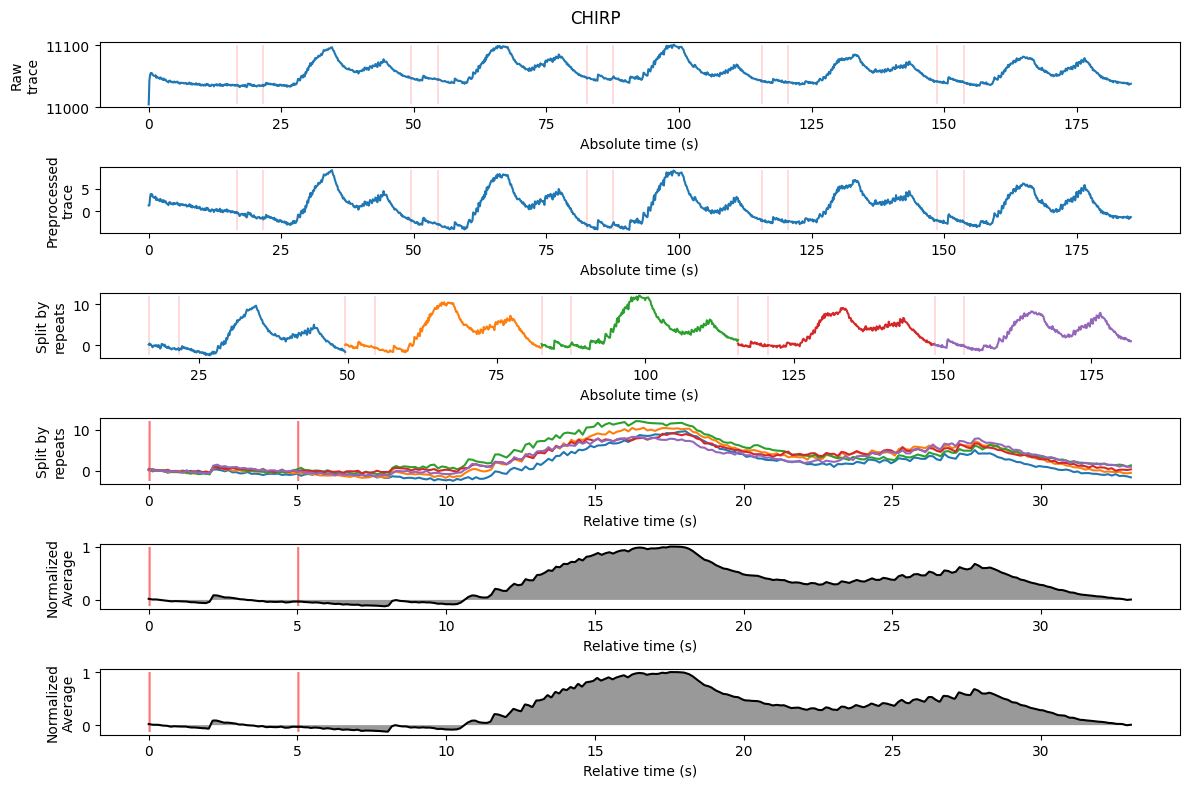

In [47]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7)].iloc[0]
plot_repeated_stim(row, prefix='chirp_')

### Local contrast saturation (CSL)

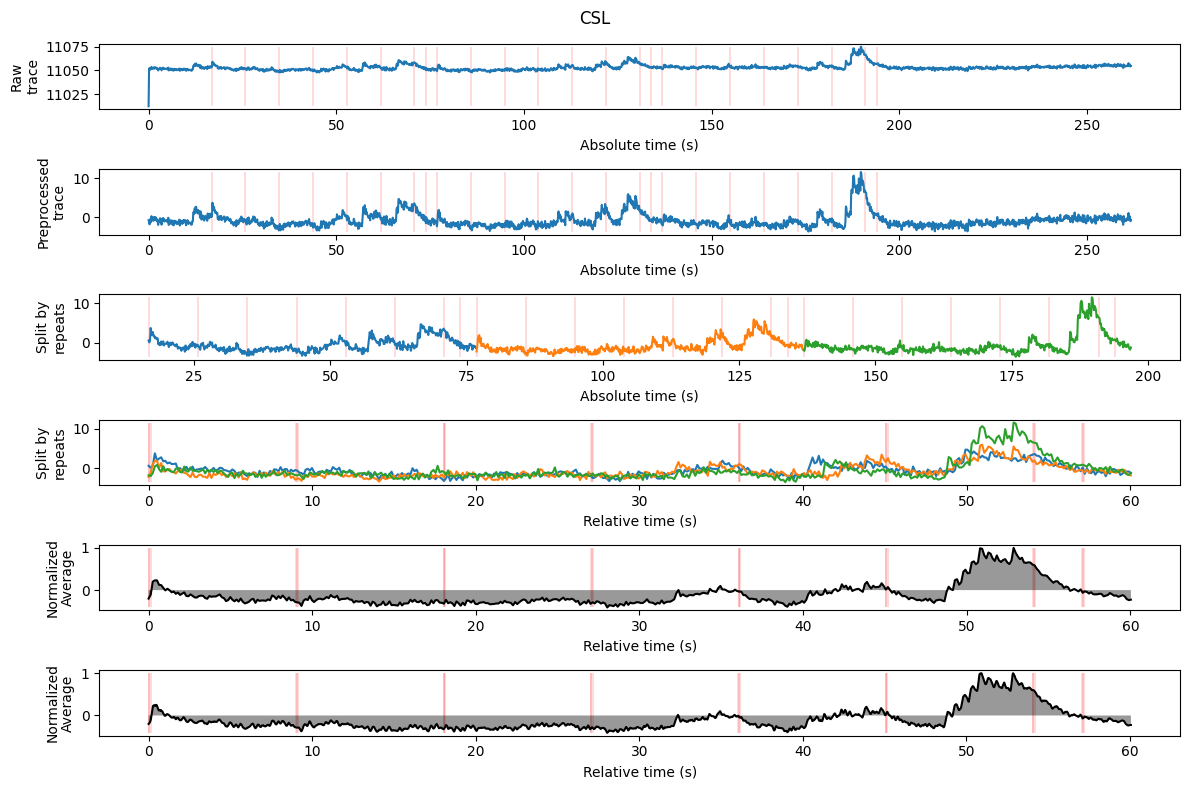

In [48]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & all_gcl_df.csl_trace.notnull()].iloc[0]
plot_repeated_stim(row, prefix='csl_')

### Moving bar

A bright moving bar stimulus on a dark background.

Note that the snippets (the individual repeats) use a local baseline estimate.

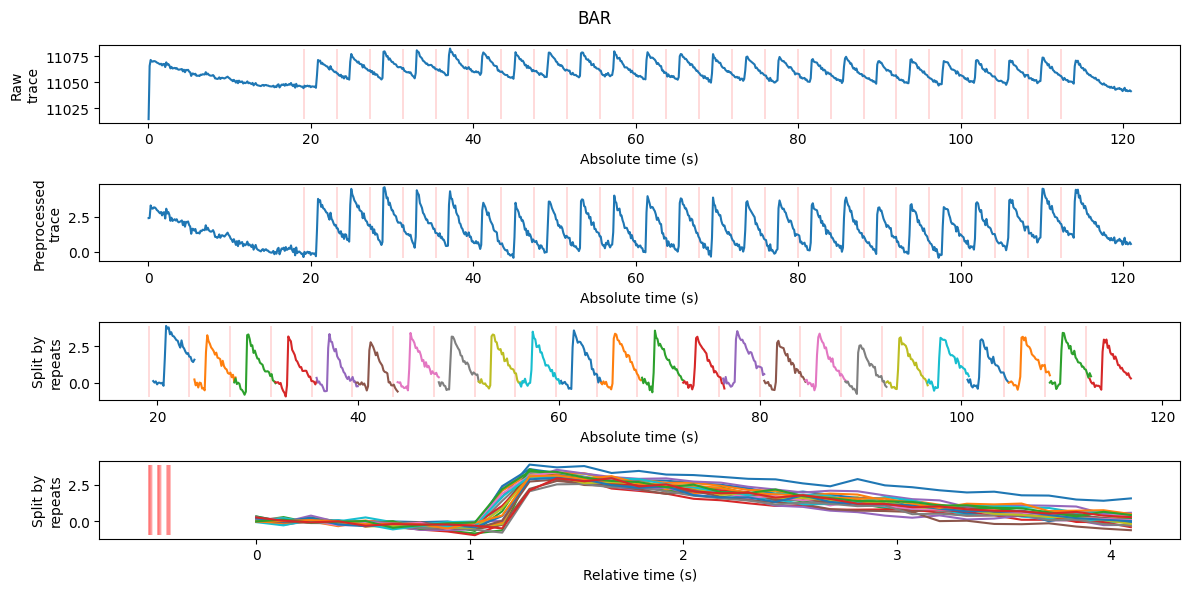

In [49]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & all_gcl_df.csl_trace.notnull()].iloc[0]
plot_repeated_stim(row, prefix='bar_', plot_avgs=False)

### Chirp interleaved

Local chirp and global chirp interleaved

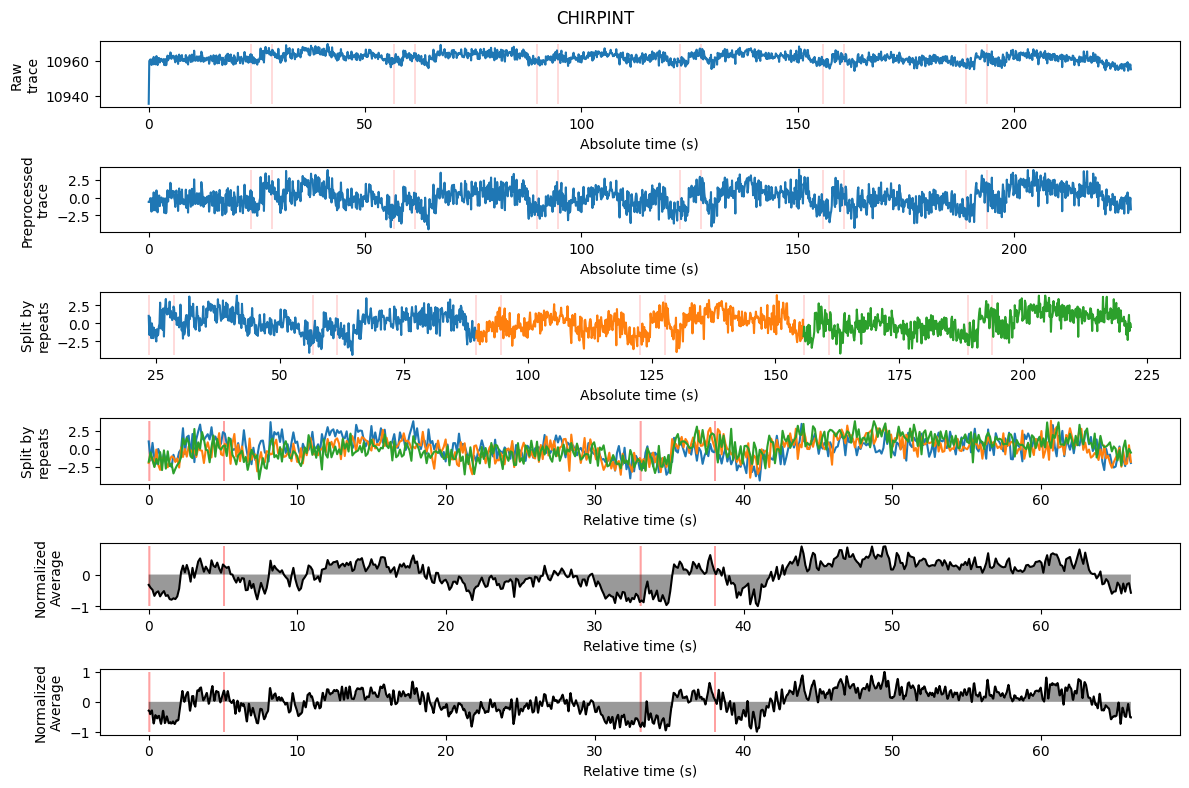

In [50]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.chirpInt_trace.notnull())].iloc[0]
plot_repeated_stim(row, prefix='chirpInt_')

## Noise stimuli

In [51]:
def plot_noise_stim(row, prefix):
    fig, axs = plt.subplot_mosaic(
        """
        AAAA
        BBBB
        CDEF
        GGHH
        """,
        height_ratios=(1, 1, 2, 2),
        figsize=(10, 8)
    )
    
    fig.suptitle(prefix[:-1].upper())
    
    ax = axs["A"]
    plot_raw_trace(ax, row, prefix=prefix)
    
    ax = axs["B"]
    plot_preprocessed_trace(ax, row, prefix=prefix)
    
    # STA frames
    rf = row[f"{prefix}rf"]
    srf = row[f"{prefix}srf"]
    trf = row[f"{prefix}trf"]
    rf_time = row[f"{prefix}rf_time"]
    vabsmax = np.max(np.abs(rf))
    h, w = rf.shape[1:3]
    extent = (0, w, 0, h)
    
    # Build frame indices: first, peaks, last (sorted, deduped)
    peak_idxs = row[f"{prefix}trf_peak_idxs"]
    idxs = np.unique(np.concatenate([[0], peak_idxs, [rf.shape[0] - 1]]))
    
    # Get tab10 colors for frame highlighting
    tab10 = plt.get_cmap('tab10')
    frame_colors = [tab10(i) for i in range(len(idxs))]
    
    # Map frames to available axes, in order
    frame_axes = ["C", "D", "E", "F"]
    for ax_key, idx, color in zip(frame_axes, idxs, frame_colors):
        ax = axs[ax_key]
        im = ax.imshow(rf[idx], vmin=-vabsmax, vmax=+vabsmax, cmap='bwr', extent=extent)
        ax.set(xlabel='x [pixel]', ylabel='y [pixel]')
        ax.set_title(f'RF frame {idx}', color=color, fontweight='bold')
    plt.colorbar(im)
    
    # Hide any unused frame axes
    for ax_key in frame_axes[len(idxs):]:
        axs[ax_key].set_visible(False)
    
    # Temporal RF with frame highlights
    ax = axs["G"]
    ax.plot(rf_time, trf, color='black', zorder=1)
    for idx, color in zip(idxs, frame_colors):
        ax.plot(rf_time[idx], trf[idx], 'o', color=color,
                markersize=8, markeredgecolor='black', markeredgewidth=0.5, zorder=2)
    ax.set(xlabel='Time (s) / Frame', ylabel='Normalized amplitude', title='Temporal RF')
    
    # Add secondary x-tick labels showing frame numbers
    primary_ticks = ax.get_xticks()
    # Keep only ticks within the data range
    tlim = (rf_time.min(), rf_time.max())
    primary_ticks = primary_ticks[(primary_ticks >= tlim[0]) & (primary_ticks <= tlim[1])]
    # Map each time tick to nearest frame index
    frame_labels = [np.argmin(np.abs(rf_time - t)) for t in primary_ticks]
    tick_labels = [f"{t:.2g}\n({f})" for t, f in zip(primary_ticks, frame_labels)]
    ax.set_xticks(primary_ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(tlim)
    
    ax = axs["H"]
    vabsmax_s = np.max(np.abs(srf))
    h, w = srf.shape
    im = ax.imshow(srf, vmin=-vabsmax_s, vmax=+vabsmax_s, cmap='bwr', extent=extent)
    ax.set(xlabel='x [pixel]', ylabel='y [pixel]', title='Spatial RF')
    plt.colorbar(im)
    
    plt.tight_layout()

### Noise
Binary dense noise with 40 µm x 40 µm pixels. 

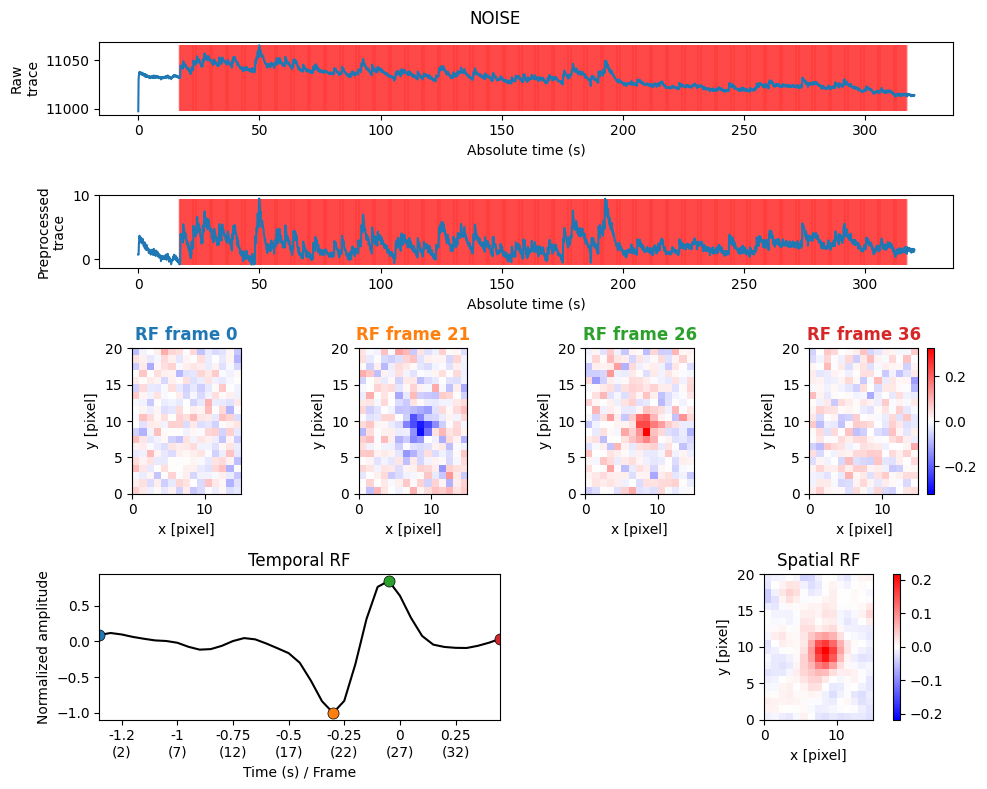

In [52]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.noise_trace.notnull())].iloc[0]
plot_noise_stim(row, prefix='noise_')

### Shifty Noise
Binary dense noise with 40 µm x 40 µm pixels that are randomly moved on 10 µm x 10 µm grid to get higher resolution RFs.

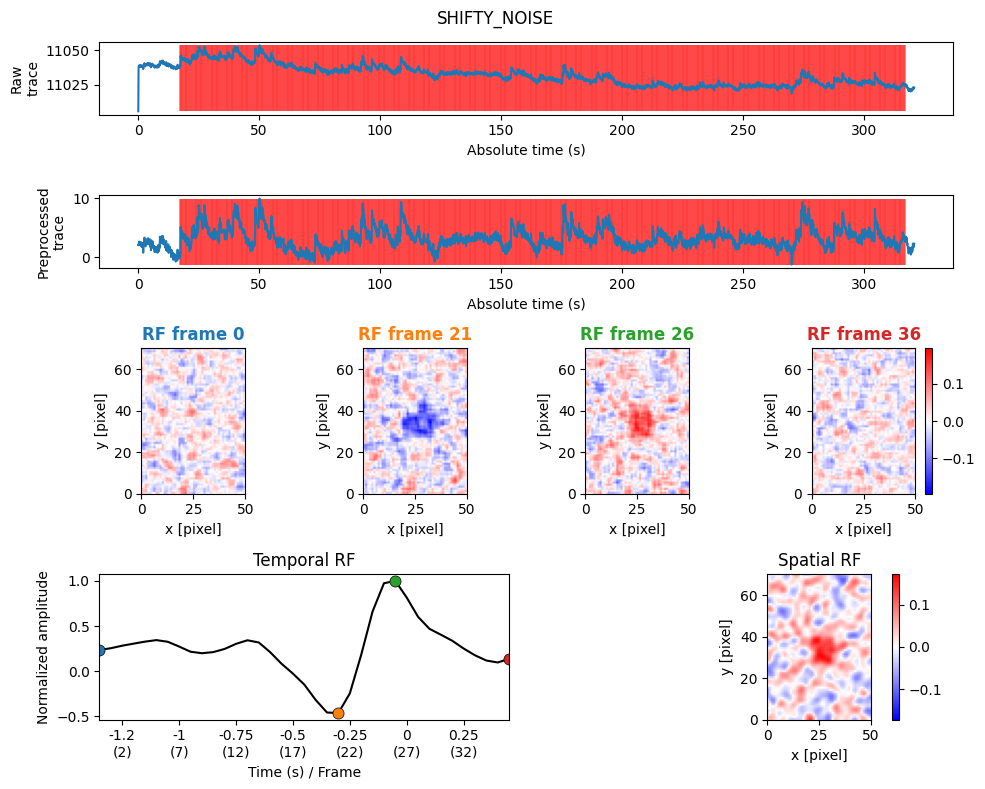

In [53]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.shifty_noise_trace.notnull())].iloc[0]
plot_noise_stim(row, prefix='shifty_noise_')

# Center surround noise stimuli

## Blue / Green
Center surround flicker stimuli in either green or UV only.

In [54]:
def plot_center_surround_stim(row, prefix, center_radius=1.0, surround_inner_radius=1, surround_outer_radius=2.5):
    fig, axs = plt.subplot_mosaic(
        """
        AAAA
        BBBB
        CDEF
        GGGG
        """,
        height_ratios=(1, 1, 2, 2),
        figsize=(10, 8)
    )
    
    fig.suptitle(prefix[:-1].upper())
    
    ax = axs["A"]
    plot_raw_trace(ax, row, prefix=prefix)
    
    ax = axs["B"]
    plot_preprocessed_trace(ax, row, prefix=prefix)
    
    # STA: rf shape is (n_time, 2, 1); index 0 = center, index 1 = surround
    rf = row[f"{prefix}rf"]
    rf_time = row[f"{prefix}rf_time"]
    
    trf_center = rf[:, 0, 0]
    trf_surround = rf[:, 1, 0]
    vabsmax = np.max(np.abs(rf))
    
    # Build frame indices from peak lags (in seconds), mapped to nearest rf_time index
    idxs = np.unique([0, np.argmin(trf_center), np.argmax(trf_center), rf.shape[0] - 1])
    
    # tab10 colors
    tab10 = plt.get_cmap('tab10')
    frame_colors = [tab10(i) for i in range(len(idxs))]
    
    # Helper: draw center disk + surround annulus colored by their values
    def draw_cs(ax, c_val, s_val, vmin, vmax, title, title_color=None):
        norm = plt.Normalize(vmin=vmin, vmax=vmax)
        cmap = plt.get_cmap('bwr')
        from matplotlib.patches import Circle, Annulus
        surround_patch = Annulus(
            (0, 0),
            r=surround_outer_radius,
            width=surround_outer_radius - surround_inner_radius,
            facecolor=cmap(norm(s_val)),
            edgecolor='black',
            linewidth=0.5,
        )
        center_patch = Circle(
            (0, 0),
            radius=center_radius,
            facecolor=cmap(norm(c_val)),
            edgecolor='black',
            linewidth=0.5,
        )
        ax.add_patch(surround_patch)
        ax.add_patch(center_patch)
        lim = surround_outer_radius * 1.1
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        if title_color is not None:
            ax.set_title(title, color=title_color, fontweight='bold')
        else:
            ax.set_title(title)
    
    # Frame panels C/D/E/F
    frame_axes = ["C", "D", "E", "F"]
    frame_norm = plt.Normalize(vmin=-vabsmax, vmax=+vabsmax)
    frame_cmap = plt.get_cmap('bwr')
    last_frame_ax = None
    for ax_key, idx, color in zip(frame_axes, idxs, frame_colors):
        ax = axs[ax_key]
        draw_cs(
            ax,
            c_val=trf_center[idx],
            s_val=trf_surround[idx],
            vmin=-vabsmax, vmax=+vabsmax,
            title=f'RF frame {idx}',
            title_color=color,
        )
        last_frame_ax = ax
    
    # Hide any unused frame axes
    for ax_key in frame_axes[len(idxs):]:
        axs[ax_key].set_visible(False)
    
    # Colorbar for frame panels, attached to the last visible frame axis
    sm = plt.cm.ScalarMappable(norm=frame_norm, cmap=frame_cmap)
    sm.set_array([])
    fig.colorbar(sm, ax=last_frame_ax, fraction=0.08, pad=0.05, label='Amplitude')
    
    # Temporal RF: solid = center, dashed = surround
    ax = axs["G"]
    ax.plot(rf_time, trf_center, color='black', linestyle='-', label='center', zorder=1)
    ax.plot(rf_time, trf_surround, color='black', linestyle='--', label='surround', zorder=1)
    
    for idx, color in zip(idxs, frame_colors):
        ax.plot(rf_time[idx], trf_center[idx], 'o', color=color,
                markersize=8, markeredgecolor='black', markeredgewidth=0.5, zorder=2)
    
    ax.set(xlabel='Time (s) / Frame', ylabel='Normalized amplitude', title='Temporal RF')
    ax.legend(loc='best')
    
    # Dual-label x-ticks
    primary_ticks = ax.get_xticks()
    tlim = (rf_time.min(), rf_time.max())
    primary_ticks = primary_ticks[(primary_ticks >= tlim[0]) & (primary_ticks <= tlim[1])]
    frame_labels = [np.argmin(np.abs(rf_time - t)) for t in primary_ticks]
    tick_labels = [f"{t:.2g}\n({f})" for t, f in zip(primary_ticks, frame_labels)]
    ax.set_xticks(primary_ticks)
    ax.set_xticklabels(tick_labels)
    ax.set_xlim(tlim)
    
    plt.tight_layout()

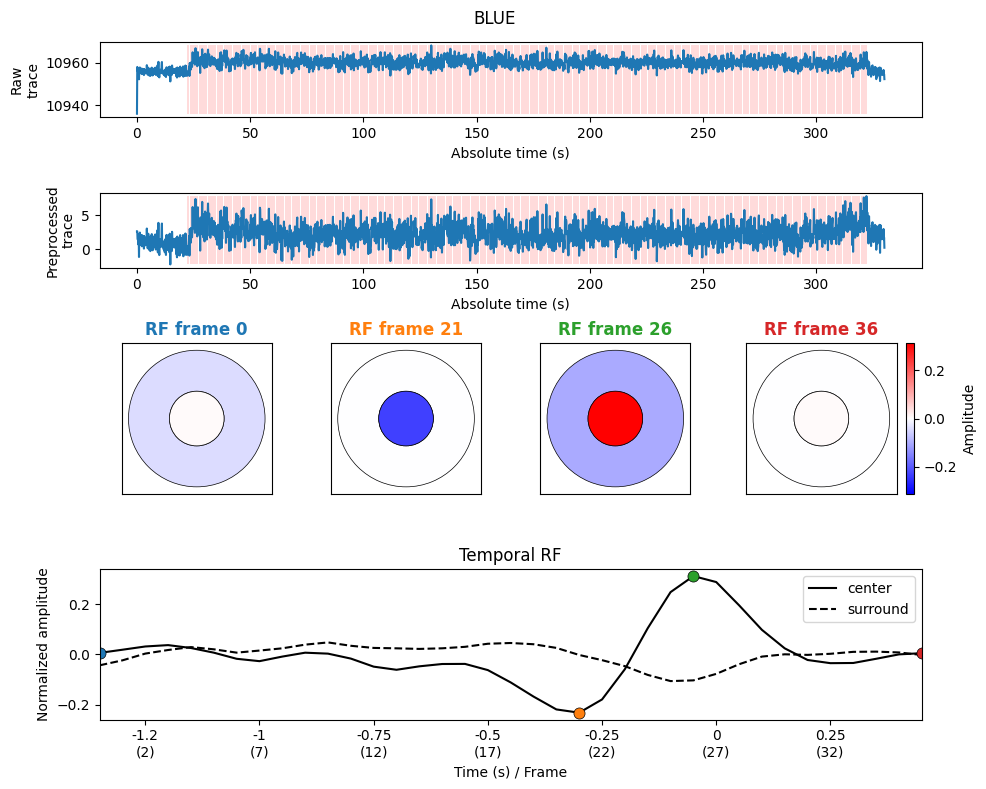

In [56]:
row = all_gcl_df[(all_gcl_df.chirp_qidx>0.6) & (all_gcl_df.bar_qidx>0.7) & (all_gcl_df.blue_trace.notnull())].iloc[0]
plot_center_surround_stim(row, prefix='blue_')